# Exploratory Data Analysis (EDA)

Project:
Explainable AI-Powered Pneumonia Diagnosis & Clinical Decision Support System

Objectives:

- Visualize NORMAL and PNEUMONIA samples
- Analyze pixel intensity distributions
- Explore image characteristics
- Identify visual patterns
- Support preprocessing decisions

In [1]:
import os
import random

import cv2
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATASET_PATH = "/content/drive/MyDrive/archive (6)/chest_xray/chest_xray"

## NORMAL Sample Visualization

Objective:

Visual inspection of healthy chest X-ray images.

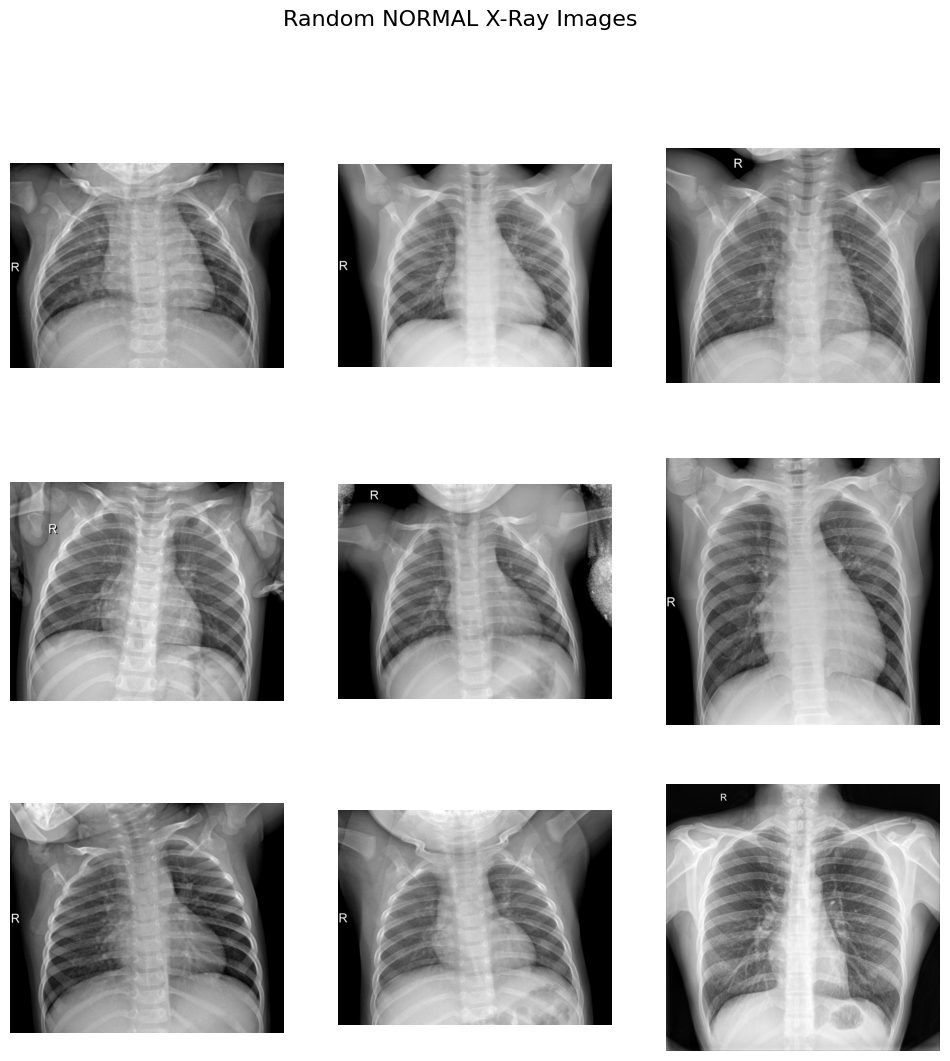

In [4]:
normal_path = os.path.join(
    DATASET_PATH,
    "train",
    "NORMAL"
)

sample_images = random.sample(
    os.listdir(normal_path),
    9
)

plt.figure(figsize=(12,12))

for i, img_name in enumerate(sample_images):

    img_path = os.path.join(
        normal_path,
        img_name
    )

    image = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(3,3,i+1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Random NORMAL X-Ray Images",
    fontsize=16
)

plt.show()

## PNUEMONIA Sample Visualization

Objective:

Visual inspection of Pneumonia chest X-ray images.

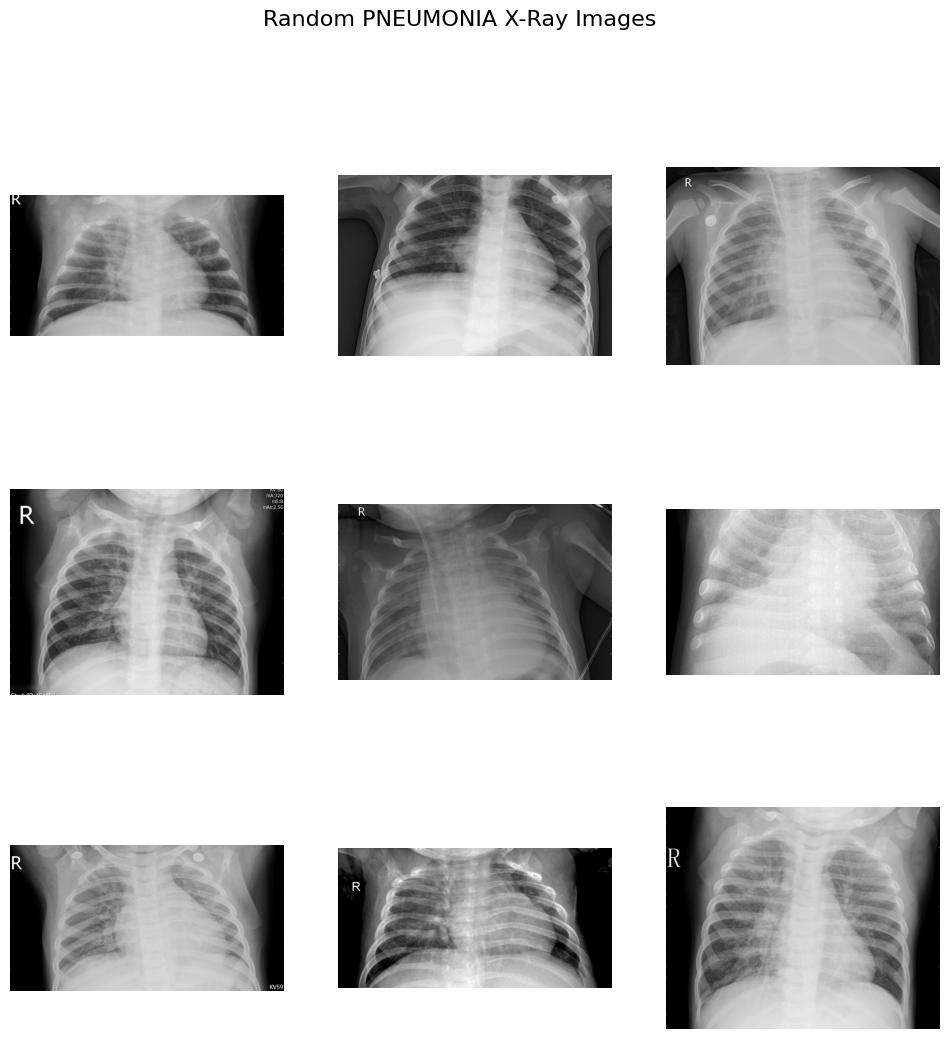

In [5]:
pneumonia_path = os.path.join(
    DATASET_PATH,
    "train",
    "PNEUMONIA"
)

sample_images = random.sample(
    os.listdir(pneumonia_path),
    9
)

plt.figure(figsize=(12,12))

for i, img_name in enumerate(sample_images):

    img_path = os.path.join(
        pneumonia_path,
        img_name
    )

    image = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(3,3,i+1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Random PNEUMONIA X-Ray Images",
    fontsize=16
)

plt.show()

## Visual Comparison Findings

### NORMAL Images

Observations:

- Relatively clear lung fields
- Lower opacity regions
- More uniform radiographic appearance
- Consistent anatomical structure

### PNEUMONIA Images

Observations:

- Increased lung opacity
- Presence of infiltrates and dense regions
- Greater visual variability
- Non-uniform lung textures

### Comparative Analysis

Visual inspection indicates that pneumonia cases exhibit distinguishable radiographic characteristics compared to normal chest X-rays.

These differences suggest that deep learning models may be capable of learning meaningful discriminative features for pneumonia classification.

### Conclusion

Preliminary visual assessment confirms the presence of class-specific radiographic patterns within the dataset.

# Pixel Intensity Distribution Analysis

Objective:

- Analyze grayscale intensity values
- Evaluate image brightness and contrast
- Support preprocessing decisions

In [6]:
pixel_values = []

In [7]:
pixel_values = []

for split in ["train"]:

    split_path = os.path.join(DATASET_PATH, split)

    for cls in os.listdir(split_path):

        if cls.startswith("."):
            continue

        cls_path = os.path.join(split_path, cls)

        sample_files = os.listdir(cls_path)

        sample_files = random.sample(
            sample_files,
            min(50, len(sample_files))
        )

        for img_name in sample_files:

            img_path = os.path.join(
                cls_path,
                img_name
            )

            image = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            if image is not None:

                # sample only part of image pixels
                sampled_pixels = image.flatten()[::20]

                pixel_values.extend(
                    sampled_pixels
                )

In [8]:
print("Total Pixels Analysed:",
      len(pixel_values))

Total Pixels Analysed: 8892962


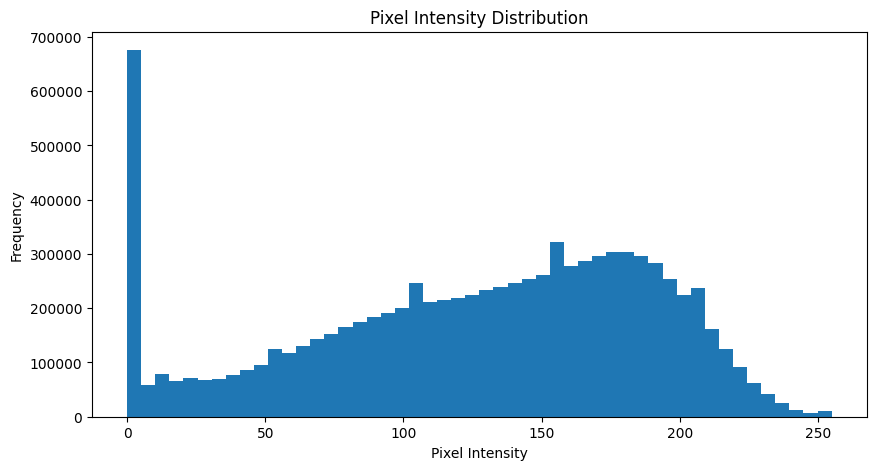

In [9]:
plt.figure(figsize=(10,5))

plt.hist(
    pixel_values,
    bins=50
)

plt.title(
    "Pixel Intensity Distribution"
)

plt.xlabel(
    "Pixel Intensity"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [10]:
print("Mean:", np.mean(pixel_values))
print("Median:", np.median(pixel_values))
print("Min:", np.min(pixel_values))
print("Max:", np.max(pixel_values))

Mean: 125.7032999803665
Median: 136.0
Min: 0
Max: 255


## Pixel Intensity Analysis

### Objective

To evaluate grayscale intensity distributions and identify potential preprocessing opportunities.

### Results

Total Pixels Analysed:

8,892,962

Intensity Statistics:

| Metric | Value |
|----------|----------|
| Mean Intensity | 125.70 |
| Median Intensity | 136.00 |
| Minimum Intensity | 0 |
| Maximum Intensity | 255 |

### Observations

- Pixel values span the complete grayscale range.
- A large proportion of pixels are concentrated within mid-intensity regions.
- A significant spike near zero intensity corresponds to image background regions.
- Intensity values are not uniformly distributed across the grayscale spectrum.

### Conclusion

The observed intensity distribution suggests that contrast enhancement techniques such as CLAHE and Histogram Equalization may improve feature visibility and should be evaluated during preprocessing experiments.

# Image Brightness Analysis

Objective:

- Measure image brightness variability
- Identify underexposed or overexposed scans
- Support preprocessing decisions

In [11]:
brightness_scores = []

In [12]:
for split in ["train"]:

    split_path = os.path.join(
        DATASET_PATH,
        split
    )

    for cls in os.listdir(split_path):

        if cls.startswith("."):
            continue

        cls_path = os.path.join(
            split_path,
            cls
        )

        sample_files = random.sample(
            os.listdir(cls_path),
            min(100, len(os.listdir(cls_path)))
        )

        for img_name in sample_files:

            img_path = os.path.join(
                cls_path,
                img_name
            )

            image = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            if image is not None:

                brightness_scores.append(
                    np.mean(image)
                )

In [13]:
print(
    "Average Brightness:",
    np.mean(brightness_scores)
)

print(
    "Minimum Brightness:",
    np.min(brightness_scores)
)

print(
    "Maximum Brightness:",
    np.max(brightness_scores)
)

Average Brightness: 121.70435755454717
Minimum Brightness: 71.4069281416453
Maximum Brightness: 174.3646215361181


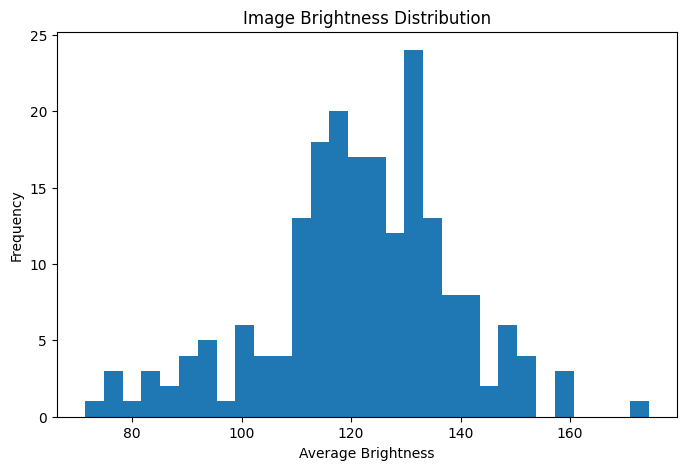

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    brightness_scores,
    bins=30
)

plt.title(
    "Image Brightness Distribution"
)

plt.xlabel(
    "Average Brightness"
)

plt.ylabel(
    "Frequency"
)

plt.show()

## Image Brightness Analysis

### Objective

To evaluate brightness variation across chest X-ray images and identify potential exposure-related inconsistencies.

### Results

| Metric | Value |
|----------|----------|
| Average Brightness | 121.70 |
| Minimum Brightness | 71.41 |
| Maximum Brightness | 174.36 |

### Observations

- Most images exhibit moderate brightness levels.
- Brightness values are concentrated around the 110–140 range.
- Some variability exists due to differing acquisition conditions and patient characteristics.
- No extreme overexposed or underexposed images were observed.

### Conclusion

Brightness variation is present but remains within a reasonable range.

Image normalization and contrast enhancement techniques will be evaluated during preprocessing experiments to further improve consistency across samples.

In [15]:
normal_brightness = []
pneumonia_brightness = []

for cls in ["NORMAL", "PNEUMONIA"]:

    cls_path = os.path.join(
        DATASET_PATH,
        "train",
        cls
    )

    sample_files = random.sample(
        os.listdir(cls_path),
        min(100, len(os.listdir(cls_path)))
    )

    for img_name in sample_files:

        img_path = os.path.join(
            cls_path,
            img_name
        )

        image = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if image is not None:

            brightness = np.mean(image)

            if cls == "NORMAL":
                normal_brightness.append(
                    brightness
                )
            else:
                pneumonia_brightness.append(
                    brightness
                )

In [16]:
print(
    "Normal Mean Brightness:",
    np.mean(normal_brightness)
)

print(
    "Pneumonia Mean Brightness:",
    np.mean(pneumonia_brightness)
)

Normal Mean Brightness: 122.9808203782338
Pneumonia Mean Brightness: 125.50903512242195


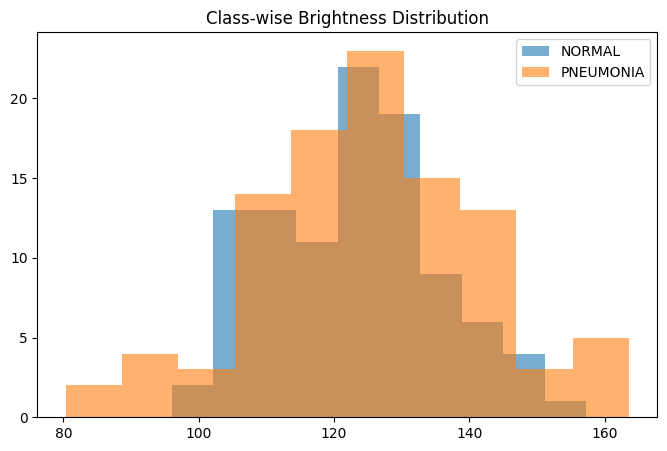

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    normal_brightness,
    alpha=0.6,
    label="NORMAL"
)

plt.hist(
    pneumonia_brightness,
    alpha=0.6,
    label="PNEUMONIA"
)

plt.legend()

plt.title(
    "Class-wise Brightness Distribution"
)

plt.show()

## Class-wise Brightness Comparison

### Results

| Class | Mean Brightness |
|---------|---------|
| NORMAL | 122.98 |
| PNEUMONIA | 125.51 |

### Observations

- Pneumonia images exhibit slightly higher average brightness compared to normal scans.
- The difference between classes is relatively small.
- Significant overlap exists between the two brightness distributions.

### Interpretation

Brightness alone is insufficient for reliable class separation.

The classification task is therefore expected to rely on more complex radiographic features such as:

- Opacity regions
- Lung infiltrates
- Texture variations
- Structural abnormalities

### Conclusion

The dataset presents a meaningful classification challenge and is unlikely to be solved using simple intensity-based heuristics alone.

# EDA Summary

## Key Findings

### Visual Analysis

- Normal and pneumonia images exhibit visibly different radiographic characteristics.
- Pneumonia images show increased opacity and infiltrate patterns.

### Pixel Intensity Analysis

- Pixel values span the complete grayscale range (0–255).
- Intensity values are concentrated in mid-to-high grayscale regions.
- Contrast enhancement techniques may improve feature visibility.

### Brightness Analysis

- Average dataset brightness is approximately 121.7.
- No severe overexposure or underexposure issues were identified.
- Moderate brightness variability exists across samples.

### Class-wise Brightness Comparison

- Pneumonia images are slightly brighter on average.
- Significant overlap exists between class distributions.
- Brightness alone is insufficient for classification.

## Conclusions

The dataset contains meaningful visual patterns suitable for deep learning-based pneumonia detection.

Findings from this EDA support the evaluation of preprocessing techniques such as:

- Resizing
- Normalization
- CLAHE
- Histogram Equalization

These techniques will be investigated in the next phase of the project.